In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import statsmodels.api as sm
from scipy.stats import fisher_exact
from pySankey.sankey import sankey
from sklearn.preprocessing import StandardScaler

In [39]:
df = pd.read_excel("Dataset_TO_Clustering.xlsx")
Dataset = df.copy()

In [40]:
Dataset['Age_Years'] = Dataset['Age_Years'].astype('float64')
Dataset.dtypes

Sex                               int64
Age_Years                       float64
Growth Delay Updated              int64
Recent_Gastroenteritis            int64
BloodCount_Microcytic_Anemia      int64
GI_Upper                          int64
GI_Diarrhea                       int64
GI_WeightLoss                     int64
GI_Meteorism                      int64
GI_AbdominalPain                  int64
GI_Anorexia                       int64
GI_Stipsis                        int64
GI_Other                          int64
Neuro_Psychiatry                  int64
Neuro_Other                       int64
Neuro_Headache                    int64
Neuro_Irritability                int64
Teeth_Anomalies                   int64
Blood_Proteins_Anomalies          int64
Asthenia                          int64
Osteopenia                        int64
Autoimmune_Tyroid_Dis             int64
Autoimmune_Type1_Diabetes         int64
Autoimmune_Skin/Tissues           int64
Autoimmune_Others                 int64


In [41]:
Age_original = Dataset['Age_Years']

scaler = StandardScaler()
Age_standardized = scaler.fit_transform(pd.DataFrame(Age_original))

In [ ]:
Dataset.drop(columns = 'Age_Years')
Dataset['Age_Years'] = Age_standardized

In [ ]:
Dataset = Dataset.drop(columns = ['EMA_categorical', 'IgA_categorical'])

## Perform DBSCAN

In [8]:
from sklearn.cluster import DBSCAN
import gower as gw

In [43]:
Dataset.columns

Index(['Sex', 'Age_Years', 'Growth Delay Updated', 'Recent_Gastroenteritis',
       'BloodCount_Microcytic_Anemia', 'GI_Upper', 'GI_Diarrhea',
       'GI_WeightLoss', 'GI_Meteorism', 'GI_AbdominalPain', 'GI_Anorexia',
       'GI_Stipsis', 'GI_Other', 'Neuro_Psychiatry', 'Neuro_Other',
       'Neuro_Headache', 'Neuro_Irritability', 'Teeth_Anomalies',
       'Blood_Proteins_Anomalies', 'Asthenia', 'Osteopenia',
       'Autoimmune_Tyroid_Dis', 'Autoimmune_Type1_Diabetes',
       'Autoimmune_Skin/Tissues', 'Autoimmune_Others', 'Common_deficit_Ig',
       'Selective_deficit_IgA', 'Down_Syndrome', 'Dermatisis_Herpetiformis',
       'Familiarity', 'Corazza_Histology', 'IgA_categorical',
       'EMA_categorical', 'HLA_binary'],
      dtype='object')

In [44]:
bool_categorical = np.ones(Dataset.columns.shape)

bool_categorical[Dataset.columns == 'Age_Years'] = 0

bool_categorical = bool_categorical.astype('bool')

In [ ]:
# the gower package already creates dummy variables and standardize numerical variables
distance_matrix = gw.gower_matrix(Dataset,cat_features=bool_categorical)


### PCoA to visualize data:

In [410]:
# PCoA using MDS
from sklearn.manifold import MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42) # By default this is the metric MDS which corresponds to PCoA
X_MDS = mds.fit_transform(distance_matrix)

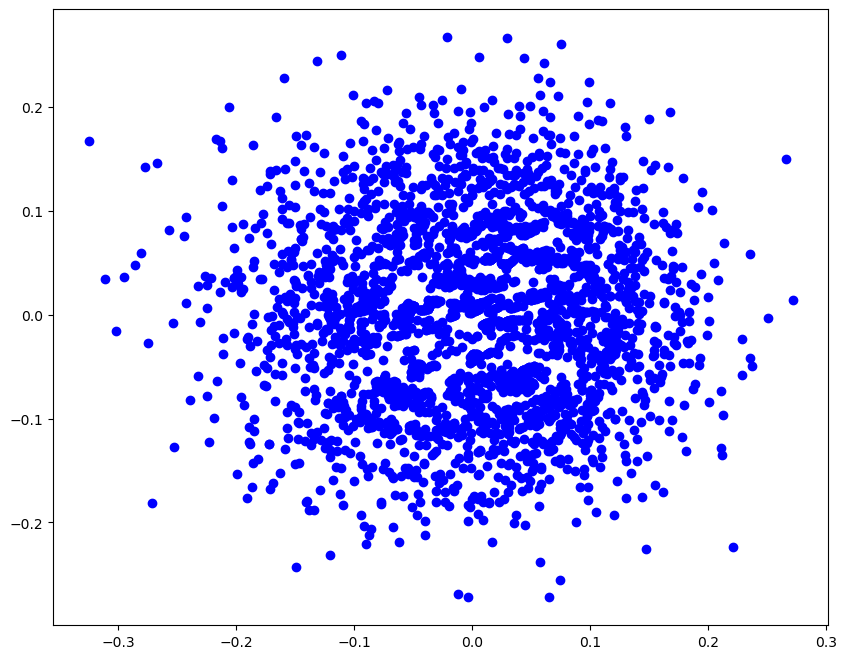

In [411]:
plt.figure(figsize=(10, 8))
plt.scatter(X_MDS[:, 0], X_MDS[:, 1], color='blue', label='Samples')

In [95]:
k = 5
kth_distances = list()
for d in distance_matrix:
    index_kth_distance = np.argsort(d)[k]
    kth_distances.append(d[index_kth_distance])

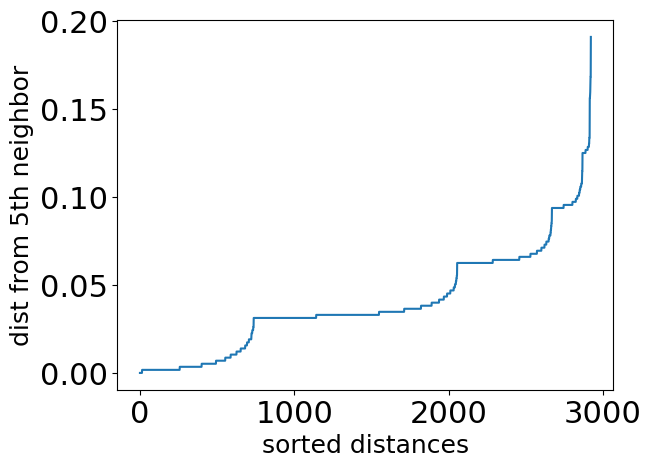

In [96]:
plt.plot(range(0, len(kth_distances)), sorted(kth_distances))
plt.ylabel('dist from %sth neighbor' % k, fontsize=18)
plt.xlabel('sorted distances', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.show()

In [97]:
dbscan = DBSCAN(eps = 0.05, min_samples = 5, metric = 'precomputed')
dbscan.fit(distance_matrix)

DBSCAN(eps=0.05, metric='precomputed')

In [98]:
np.unique(dbscan.labels_, return_counts = True)

(array([-1,  0], dtype=int64), array([ 483, 2439], dtype=int64))

## DBSCAN after PCA:

In [46]:
from sklearn.decomposition import PCA

projection_dimension = 2 # to allow plot in two dimensions
rnd = 1
data_projection = PCA(n_components = projection_dimension, random_state = rnd)

X = distance_matrix.copy()

X = data_projection.fit_transform(X)

In [101]:
from scipy.spatial.distance import pdist, squareform

In [ ]:
dist = pdist(X, 'euclidean') #pair wise distance
dist = squareform(dist) #distance matrix given the vector dist

In [103]:
k = 3
kth_distances = list()
for d in dist:
    index_kth_distance = np.argsort(d)[k]
    kth_distances.append(d[index_kth_distance])

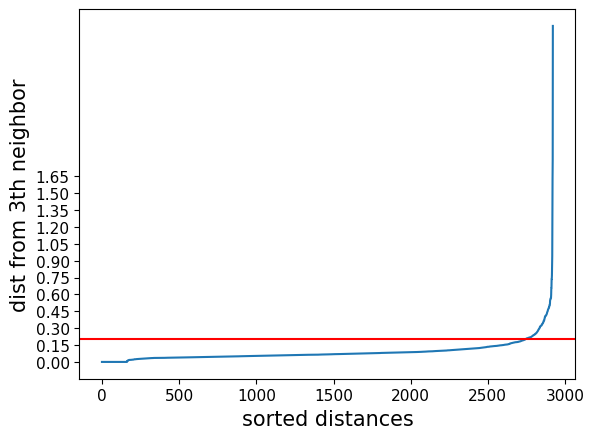

In [104]:
plt.plot(range(0, len(kth_distances)), sorted(kth_distances))
plt.ylabel('dist from %sth neighbor' % k, fontsize=15)
plt.xlabel('sorted distances', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=11)
plt.yticks(np.arange(0.0, 1.8, 0.15))

plt.axhline(y = 0.2, color = 'r', label = 'Horizontal_Line')
plt.show()

In [105]:
dbscan = DBSCAN(eps = 0.2, min_samples = 3, metric = 'euclidean')
dbscan.fit(X)

DBSCAN(eps=0.2, min_samples=3)

In [106]:
np.unique(dbscan.labels_, return_counts = True)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15],
       dtype=int64),
 array([ 106, 2603,   43,   51,    9,    4,   10,   10,   32,   25,    3,
           3,    3,    6,    7,    4,    3], dtype=int64))

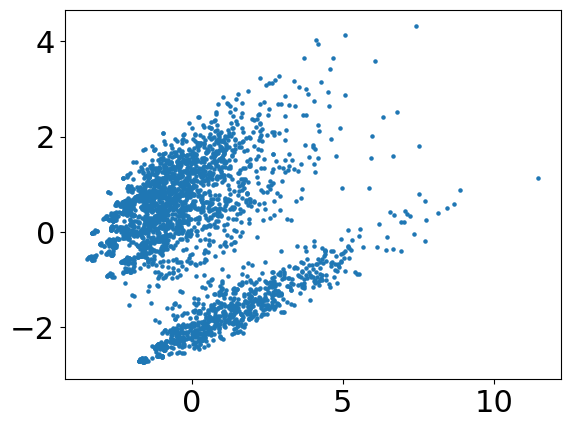

In [48]:
plt.scatter(X[:,0], X[:,1], s = 5)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.show()

The subdivision in 2 natural clusters is due to the combined effect of EMA_categorical and IgA_categorical, with a stronger impact given by EMA_categorical. Indeed, by removing only IgA_categorical from the Dataset, we can appreciate a first visual split of the data in the 2D plot after PCA. By removing both variables, the plotted data seems to be in only one cluster, NO more visual natural clustering can be seen.

## Features impact analysis: try different strategies of grouping related variables to make them stronger in terms of clustering impact (for now considering clustering after PCA)

Firstly, create a copy of the dataset (with EMA and IgA) on which we can work

In [ ]:
data = Dataset.copy()

### First attempt: group together all GI symptoms

In [ ]:
data['GI'] = 0

data['GI'][data['GI_Upper']==1] = 1
data['GI'][data['GI_Diarrhea']==1] = 1
data['GI'][data['GI_WeightLoss']==1] = 1
data['GI'][data['GI_Meteorism']==1] = 1
data['GI'][data['GI_AbdominalPain']==1] = 1
data['GI'][data['GI_Anorexia']==1] = 1
data['GI'][data['GI_Stipsis']==1] = 1
data['GI'][data['GI_Other']==1] = 1

data = data.drop(columns = ['GI_Upper', 'GI_Diarrhea', 'GI_WeightLoss', 'GI_Meteorism', 'GI_AbdominalPain', 'GI_Anorexia', 'GI_Stipsis', 'GI_Other'])


Attempt with three classes: Gastro, intestinal and systemic (Weightloss, Anorexia and Others) symptomps

In [ ]:
'''data['Gastro'] = 0
data['Gastro'][data['GI_Upper']==1] = 1

data['Systemic'] = 0
data['Systemic'][data['GI_WeightLoss']==1] = 1
data['Systemic'][data['GI_Anorexia']==1] = 1
data['Systemic'][data['GI_Other']==1] = 1

data['Intestinal'] = 0
data['Intestinal'][data['GI_Diarrhea']==1] = 1
data['Intestinal'][data['GI_Meteorism']==1] = 1
data['Intestinal'][data['GI_AbdominalPain']==1] = 1
data['Intestinal'][data['GI_Stipsis']==1] = 1

data = data.drop(columns = ['GI_Upper', 'GI_Diarrhea', 'GI_WeightLoss', 'GI_Meteorism', 'GI_AbdominalPain', 'GI_Anorexia', 'GI_Stipsis', 'GI_Other'])

data'''

In [346]:
bool_categorical = np.ones(data.columns.shape)

bool_categorical[data.columns == 'Age_Years'] = 0

bool_categorical = bool_categorical.astype('bool')

In [ ]:
distance_matrix = gw.gower_matrix(data,cat_features=bool_categorical)

In [348]:
from sklearn.decomposition import PCA

projection_dimension = 2 # to allow plot in two dimensions
rnd = 1
data_projection = PCA(n_components = projection_dimension, random_state = rnd)

X = distance_matrix.copy()

X = data_projection.fit_transform(X)

In [ ]:
from scipy.spatial.distance import pdist, squareform
dist = pdist(X, 'euclidean') #pair wise distance
dist = squareform(dist) #distance matrix given the vector dist

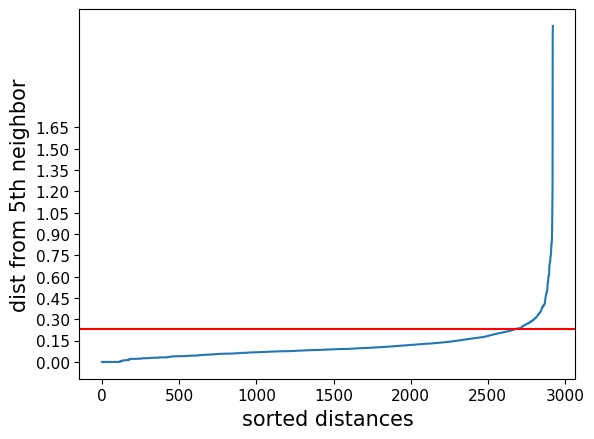

In [351]:
k = 5
kth_distances = list()
for d in dist:
    index_kth_distance = np.argsort(d)[k]
    kth_distances.append(d[index_kth_distance])

plt.plot(range(0, len(kth_distances)), sorted(kth_distances))
plt.ylabel('dist from %sth neighbor' % k, fontsize=15)
plt.xlabel('sorted distances', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=11)
plt.yticks(np.arange(0.0, 1.8, 0.15))

plt.axhline(y = 0.23, color = 'r', label = 'Horizontal_Line')
plt.show()

In [352]:
dbscan = DBSCAN(eps = 0.23, min_samples = 5, metric = 'euclidean')
dbscan.fit(X)

DBSCAN(eps=0.23)

In [353]:
np.unique(dbscan.labels_, return_counts = True)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15],
       dtype=int64),
 array([ 106, 2505,   32,   34,   47,   22,   11,   13,   88,   12,   14,
           5,    7,    6,   10,    5,    5], dtype=int64))

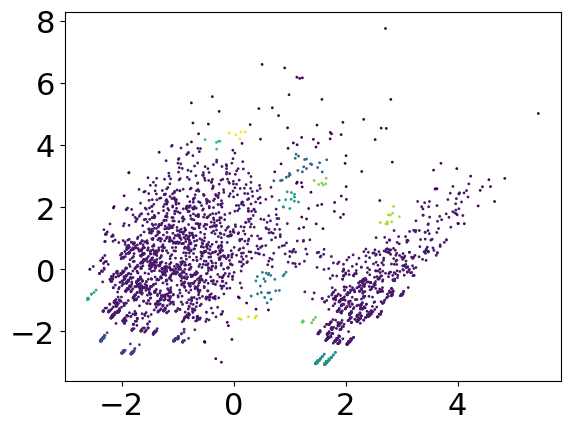

In [354]:
plt.scatter(X[:,0], X[:,1], c=dbscan.labels_, s=1)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.show()

In [355]:
# PCoA using MDS
from sklearn.manifold import MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42) # By default this is the metric MDS which corresponds to PCoA
X_MDS = mds.fit_transform(distance_matrix)

In [ ]:
from scipy.spatial.distance import pdist, squareform
dist = pdist(X_MDS, 'euclidean') #pair wise distance
dist = squareform(dist) #distance matrix given the vector dist

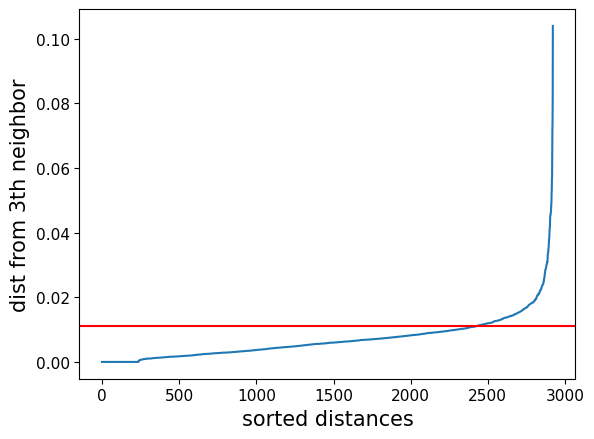

In [376]:
k = 3
kth_distances = list()
for d in dist:
    index_kth_distance = np.argsort(d)[k]
    kth_distances.append(d[index_kth_distance])

plt.plot(range(0, len(kth_distances)), sorted(kth_distances))
plt.ylabel('dist from %sth neighbor' % k, fontsize=15)
plt.xlabel('sorted distances', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=11)
plt.yticks()

plt.axhline(y = 0.011, color = 'r', label = 'Horizontal_Line')
plt.show()

In [361]:
dbscan = DBSCAN(eps = 0.011, min_samples = 3, metric = 'euclidean')
dbscan.fit(X_MDS)

DBSCAN(eps=0.011, min_samples=3)

In [362]:
np.unique(dbscan.labels_, return_counts = True)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
        33, 34, 35, 36, 37, 38, 39], dtype=int64),
 array([ 188, 1400,   22,    8,  290,    7,   86,    4,   34,    3,    4,
         691,    6,    3,    8,    9,    3,    6,    7,    4,    4,    3,
           4,   36,    3,    3,    4,    3,    4,    8,    3,    3,    5,
           4,   29,    3,    5,    3,    3,    5,    4], dtype=int64))

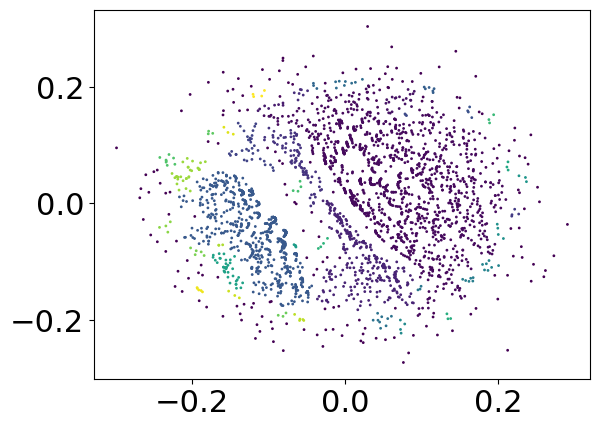

In [363]:
plt.scatter(X_MDS[:,0], X_MDS[:,1], c=dbscan.labels_, s=1)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.show()

### Second attempt: group together also all Neurological Symptoms

In [ ]:
data['Neuro'] = 0

data['Neuro'][data['Neuro_Psychiatry']==1] = 1
data['Neuro'][data['Neuro_Other']==1] = 1
data['Neuro'][data['Neuro_Headache']==1] = 1
data['Neuro'][data['Neuro_Irritability']==1] = 1

data = data.drop(columns = ['Neuro_Psychiatry', 'Neuro_Other', 'Neuro_Headache', 'Neuro_Irritability'])

data

In [ ]:
bool_categorical = np.ones(data.columns.shape)

bool_categorical[data.columns == 'Age_Years'] = 0

bool_categorical = bool_categorical.astype('bool')

distance_matrix = gw.gower_matrix(data,cat_features=bool_categorical)

In [ ]:
from sklearn.decomposition import PCA

projection_dimension = 2 # to allow plot in two dimensions
rnd = 1
data_projection = PCA(n_components = projection_dimension, random_state = rnd)

X = distance_matrix.copy()

X = data_projection.fit_transform(X)


In [ ]:
from scipy.spatial.distance import pdist, squareform
dist = pdist(X, 'euclidean') #pair wise distance
dist = squareform(dist) #distance matrix given the vector dist

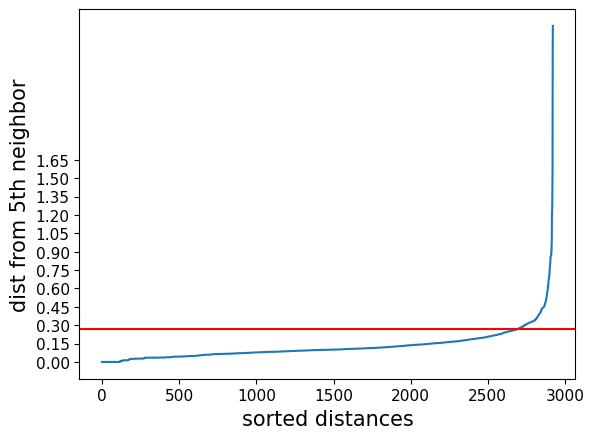

In [368]:
k = 5
kth_distances = list()
for d in dist:
    index_kth_distance = np.argsort(d)[k]
    kth_distances.append(d[index_kth_distance])

plt.plot(range(0, len(kth_distances)), sorted(kth_distances))
plt.ylabel('dist from %sth neighbor' % k, fontsize=15)
plt.xlabel('sorted distances', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=11)
plt.yticks(np.arange(0.0, 1.8, 0.15))

plt.axhline(y = 0.27, color = 'r', label = 'Horizontal_Line')
plt.show()

In [369]:
dbscan = DBSCAN(eps = 0.27, min_samples = 5, metric = 'euclidean')
dbscan.fit(X)

DBSCAN(eps=0.27)

In [370]:
np.unique(dbscan.labels_, return_counts = True)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13],
       dtype=int64),
 array([ 102, 1853,   34,   47,   12,  724,    6,   88,   14,    6,    9,
           6,   11,    5,    5], dtype=int64))

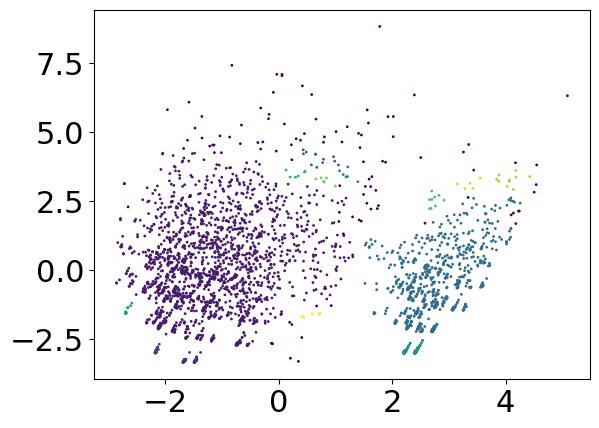

In [371]:
plt.scatter(X[:,0], X[:,1], c=dbscan.labels_, s=1)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.show()

In [372]:
# PCoA using MDS
from sklearn.manifold import MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42) # By default this is the metric MDS which corresponds to PCoA
X_MDS = mds.fit_transform(distance_matrix)

In [ ]:
from scipy.spatial.distance import pdist, squareform
dist = pdist(X_MDS, 'euclidean') #pair wise distance
dist = squareform(dist) #distance matrix given the vector dist

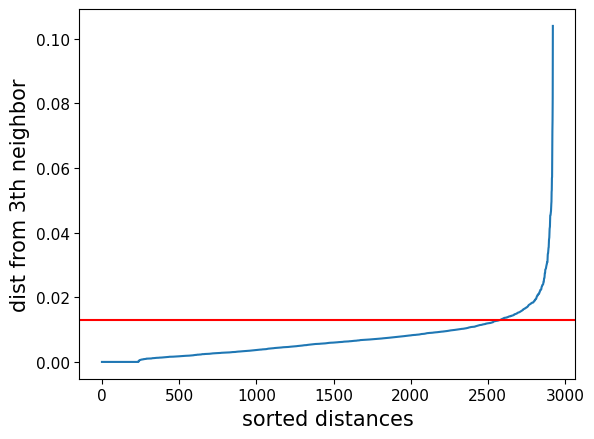

In [375]:
k = 3
kth_distances = list()
for d in dist:
    index_kth_distance = np.argsort(d)[k]
    kth_distances.append(d[index_kth_distance])

plt.plot(range(0, len(kth_distances)), sorted(kth_distances))
plt.ylabel('dist from %sth neighbor' % k, fontsize=15)
plt.xlabel('sorted distances', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=11)
plt.yticks()

plt.axhline(y = 0.013, color = 'r', label = 'Horizontal_Line')
plt.show()

In [377]:
dbscan = DBSCAN(eps = 0.013, min_samples = 3, metric = 'euclidean')
dbscan.fit(X_MDS)

DBSCAN(eps=0.013, min_samples=3)

In [379]:
np.unique(dbscan.labels_, return_counts=True)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32],
       dtype=int64),
 array([ 148, 1824,    3,    3,    3,    4,   10,   15,  789,    7,    9,
           3,    3,   13,   11,    7,    3,    3,    4,    4,    6,    3,
           4,    3,    4,    7,    4,    3,    3,    4,    4,    3,    4,
           4], dtype=int64))

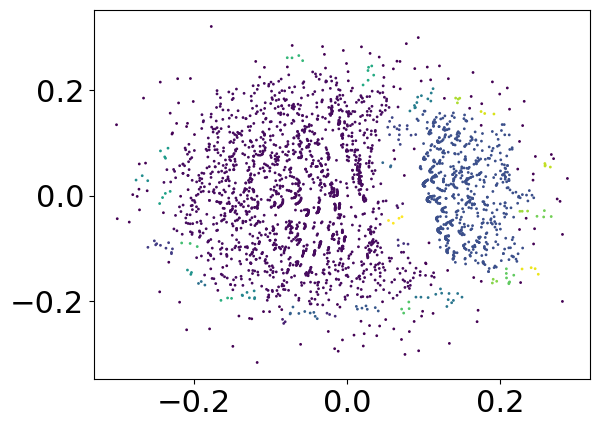

In [380]:
plt.scatter(X_MDS[:,0], X_MDS[:,1], c=dbscan.labels_, s=1)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.show()

### Third attempt: group together all Autoimmune Diseases

In [ ]:
data['Auto'] = 0

data['Auto'][data['Autoimmune_Tyroid_Dis']==1] = 1
data['Auto'][data['Autoimmune_Type1_Diabetes']==1] = 1
data['Auto'][data['Autoimmune_Skin/Tissues']==1] = 1
data['Auto'][data['Autoimmune_Others']==1] = 1

data = data.drop(columns = ['Autoimmune_Tyroid_Dis', 'Autoimmune_Type1_Diabetes', 'Autoimmune_Skin/Tissues', 'Autoimmune_Others'])


In [ ]:
bool_categorical = np.ones(data.columns.shape)

bool_categorical[data.columns == 'Age_Years'] = 0

bool_categorical = bool_categorical.astype('bool')

distance_matrix = gw.gower_matrix(data,cat_features=bool_categorical)

In [ ]:
from sklearn.decomposition import PCA

projection_dimension = 2 # to allow plot in two dimensions
rnd = 1
data_projection = PCA(n_components = projection_dimension, random_state = rnd)

X = distance_matrix.copy()

X = data_projection.fit_transform(X)


In [ ]:
from scipy.spatial.distance import pdist, squareform
dist = pdist(X, 'euclidean') #pair wise distance
dist = squareform(dist) #distance matrix given the vector dist

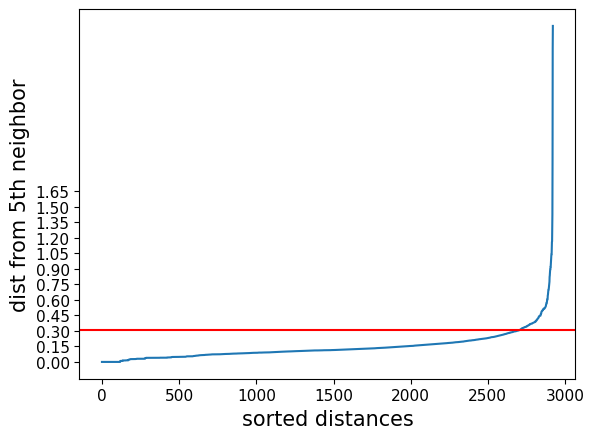

In [389]:
k = 5
kth_distances = list()
for d in dist:
    index_kth_distance = np.argsort(d)[k]
    kth_distances.append(d[index_kth_distance])

plt.plot(range(0, len(kth_distances)), sorted(kth_distances))
plt.ylabel('dist from %sth neighbor' % k, fontsize=15)
plt.xlabel('sorted distances', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=11)
plt.yticks(np.arange(0.0, 1.8, 0.15))

plt.axhline(y = 0.31, color = 'r', label = 'Horizontal_Line')
plt.show()

In [390]:
dbscan = DBSCAN(eps = 0.31, min_samples = 5, metric = 'euclidean')
dbscan.fit(X)

DBSCAN(eps=0.31)

In [391]:
np.unique(dbscan.labels_, return_counts = True)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=int64),
 array([ 102, 1830,   34,   47,   31,   15,  726,   88,   10,   14,   10,
          10,    5], dtype=int64))

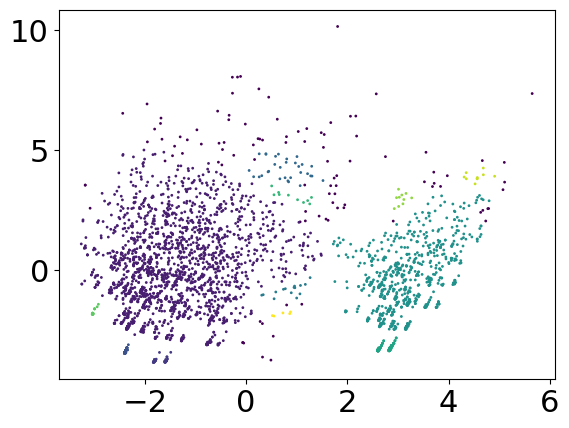

In [392]:
plt.scatter(X[:,0], X[:,1], c=dbscan.labels_, s=1)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.show()

In [393]:
# PCoA using MDS
from sklearn.manifold import MDS
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42) # By default this is the metric MDS which corresponds to PCoA
X_MDS = mds.fit_transform(distance_matrix)

In [ ]:
from scipy.spatial.distance import pdist, squareform
dist = pdist(X_MDS, 'euclidean') #pair wise distance
dist = squareform(dist) #distance matrix given the vector dist

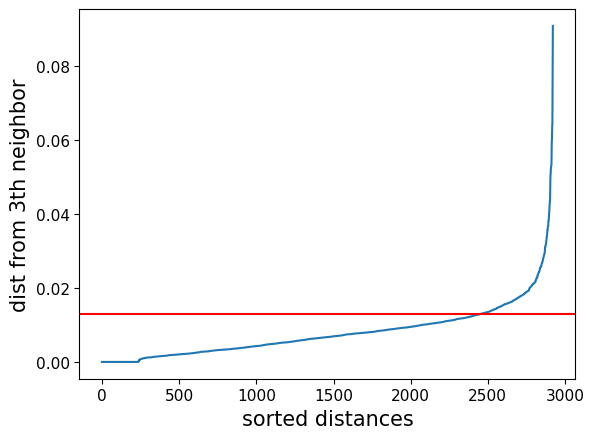

In [395]:
k = 3
kth_distances = list()
for d in dist:
    index_kth_distance = np.argsort(d)[k]
    kth_distances.append(d[index_kth_distance])

plt.plot(range(0, len(kth_distances)), sorted(kth_distances))
plt.ylabel('dist from %sth neighbor' % k, fontsize=15)
plt.xlabel('sorted distances', fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=11)
plt.yticks()

plt.axhline(y = 0.013, color = 'r', label = 'Horizontal_Line')
plt.show()

In [402]:
dbscan = DBSCAN(eps = 0.013, min_samples = 3, metric = 'euclidean')
dbscan.fit(X_MDS)

DBSCAN(eps=0.013, min_samples=3)

In [403]:
np.unique(dbscan.labels_, return_counts = True)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
        33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
        50, 51, 52, 53, 54, 55, 56, 57, 58], dtype=int64),
 array([ 214, 1073,    3,    3,   13,  106,   51,   42,  162,   21,    3,
           3,  169,    8,   18,   16,    4,   11,    5,   62,    5,   17,
         691,   13,   30,   11,    4,    8,   10,    3,    3,    3,    7,
           4,    7,    3,    3,    4,    4,    6,    5,    3,    5,    3,
           7,   10,    3,    7,    3,    8,    3,    9,    4,    5,    8,
           4,    3,    3,    3,    3], dtype=int64))

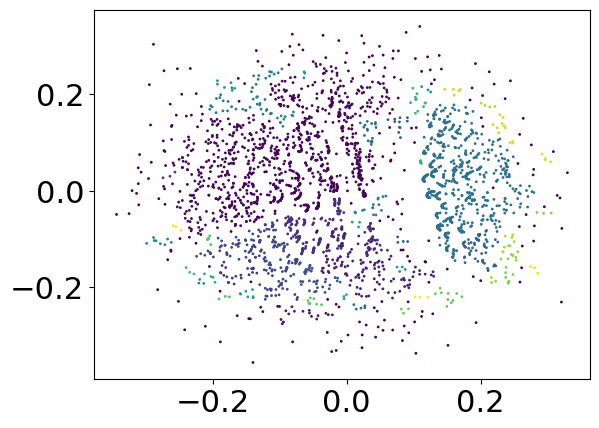

In [404]:
plt.scatter(X_MDS[:,0], X_MDS[:,1], c=dbscan.labels_, s=1)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.show()